# Notebook 01 — Coleta de Dados e Análise Exploratória (EDA)

> **Objetivo geral:** Coletar séries temporais do Banco Central do Brasil (BCB) relacionadas ao mercado de crédito e fazer uma análise exploratória antes de construir modelos preditivos de inadimplência.

In [1]:
!pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip install python-bcb




[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## Importações e Primeira Série: Inadimplência Total


- `sgs.get({"inad_total": 21082}, ...)` → baixa a série **21082** do SGS/BCB, que representa a **taxa de inadimplência total da carteira de crédito** do sistema financeiro brasileiro (em %)
- `start="2019-01-01"` → coleta dados a partir de janeiro de 2019
- A data é convertida para o tipo `datetime` do pandas, garantindo manipulação correta de séries temporais

O gráfico de linha gerado mostra a **evolução da inadimplência ao longo do tempo**, com área preenchida para facilitar a visualização de tendências.

> Inadimplência é o percentual de operações de crédito com atraso superior a 90 dias em relação ao total da carteira.



Dados coletados: 87 observações
Período: 2019-01-01 00:00:00 a 2026-03-01 00:00:00
Inadimplência atual: 4.33%


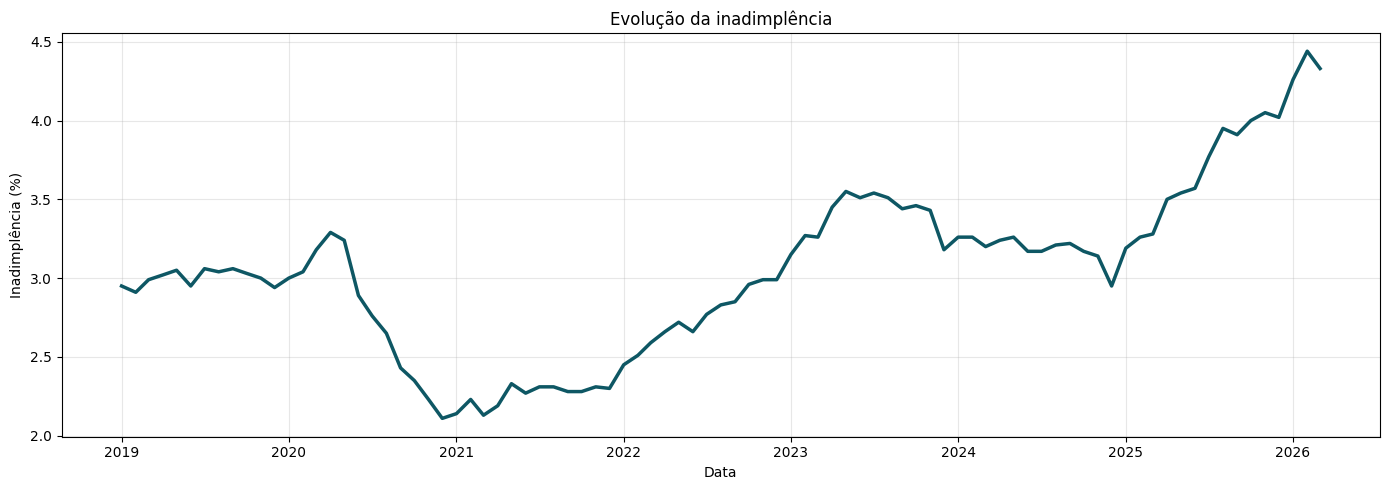

,data,inad_total
0,2019-01-01,2.95
1,2019-02-01,2.91
2,2019-03-01,2.99
3,2019-04-01,3.02
4,2019-05-01,3.05
...,...,...
82,2025-11-01,4.05
83,2025-12-01,4.02
84,2026-01-01,4.26
85,2026-02-01,4.44


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from bcb import sgs
import warnings

warnings.filterwarnings("ignore")

# Série-alvo
inad_total = sgs.get({"inad_total": 21082}, start="2019-01-01")
inad_total = inad_total.reset_index()
inad_total.columns = ["data", "inad_total"]
inad_total["data"] = pd.to_datetime(inad_total["data"])

print(f"Dados coletados: {len(inad_total)} observações")
print(f"Período: {inad_total['data'].min()} a {inad_total['data'].max()}")
print(f"Inadimplência atual: {inad_total['inad_total'].iloc[-1]:.2f}%")

# Gráfico de linha
plt.figure(figsize=(14, 5))

plt.plot(
    inad_total["data"],
    inad_total["inad_total"],
    linewidth=2.5,
    color="#0e5764"
)

plt.xlabel("Data")
plt.ylabel("Inadimplência (%)")
plt.title("Evolução da inadimplência")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

inad_total

## Análise Exploratória: Visão Geral e Estatísticas

Antes de modelar, é essencial entender os dados:
- **Quantos registros?** → determina os conjuntos de treino e teste
- **Há valores faltantes?** → dados incompletos comprometem o modelo
- **Quais os tipos?** → garante que as datas sejam tratadas corretamente

As estatísticas descritivas são complementadas com:
- `mediana` → mais robusta a outliers do que a média
- `amplitude` → diferença entre máximo e mínimo
- `coef_variacao` → desvio padrão ÷ média; mede a dispersão relativa

In [4]:
print("=== VISÃO GERAL DA BASE ===")
print(f"Número de linhas: {inad_total.shape[0]}")
print(f"Número de colunas: {inad_total.shape[1]}")
print(f"Período da base: {inad_total['data'].min().date()} até {inad_total['data'].max().date()}")

print("\n=== TIPOS DAS VARIÁVEIS ===")
print(inad_total.dtypes)

print("\n=== VALORES FALTANTES ===")
faltantes = inad_total[["inad_total"]].isna().sum().to_frame("qtd_faltantes")
faltantes["pct_faltantes"] = (faltantes["qtd_faltantes"] / len(inad_total) * 100).round(2)
print(faltantes)

print("\n=== PRIMEIRAS LINHAS ===")
print(inad_total.head())

print("\n=== ÚLTIMAS LINHAS ===")
print(inad_total.tail())

=== VISÃO GERAL DA BASE ===
Número de linhas: 87
Número de colunas: 2
Período da base: 2019-01-01 até 2026-03-01

=== TIPOS DAS VARIÁVEIS ===
data          datetime64[us]
inad_total           float64
dtype: object

=== VALORES FALTANTES ===
            qtd_faltantes  pct_faltantes
inad_total              0            0.0

=== PRIMEIRAS LINHAS ===
        data  inad_total
0 2019-01-01        2.95
1 2019-02-01        2.91
2 2019-03-01        2.99
3 2019-04-01        3.02
4 2019-05-01        3.05

=== ÚLTIMAS LINHAS ===
         data  inad_total
82 2025-11-01        4.05
83 2025-12-01        4.02
84 2026-01-01        4.26
85 2026-02-01        4.44
86 2026-03-01        4.33


In [5]:
estatisticas = inad_total[["inad_total"]].describe().T

estatisticas["mediana"] = inad_total["inad_total"].median()
estatisticas["amplitude"] = estatisticas["max"] - estatisticas["min"]
estatisticas["coef_variacao"] = (estatisticas["std"] / estatisticas["mean"]).round(4)

print("=== ESTATÍSTICAS DESCRITIVAS — INADIMPLÊNCIA TOTAL ===")
print(estatisticas[[
    "count", "mean", "mediana", "std", "min", "max", "amplitude", "coef_variacao"
]].round(4))

=== ESTATÍSTICAS DESCRITIVAS — INADIMPLÊNCIA TOTAL ===
            count    mean  mediana     std   min   max  amplitude  \
inad_total   87.0  3.0494     3.05  0.5356  2.11  4.44       2.33   

            coef_variacao  
inad_total         0.1757  


## Estrutura de Defasagens (Lags) da Série

Na modelagem de séries temporais, os valores passados da própria série (chamado de **lag** ou defasagem) são utilizados como preditores do valor presente.
A base gerada neste notebook mantém o valor observado da inadimplência no mês de referência (`inad_total`) e adiciona suas defasagens de 1 a 6 meses (`inad_total_L1` a `inad_total_L6`).

A lógica de construção segue a notação:

$$I_t \leftarrow I_{t-1}$$
$$I_t \leftarrow I_{t-1} \| I_{t-2}$$
$$I_t \leftarrow I_{t-1} \| I_{t-2} \| \ldots \| I_{t-6}$$

em que:

- `inad_total` representa a inadimplência observada no mês de referência `t`;
- `inad_total_L1` representa a inadimplência observada em `t-1`;
- `inad_total_L2` representa a inadimplência observada em `t-2`;
- e assim sucessivamente até `inad_total_L6`.

Neste notebook, ainda não é criada a variável-alvo da previsão. O alvo será definido no Notebook 02, conforme o horizonte escolhido. Para a previsão em `h=1`, a linha referente ao mês `t` será usada para prever a inadimplência em `t+1`.

In [6]:
df_lags = inad_total[["data", "inad_total"]].copy()

df_lags = df_lags.sort_values("data").reset_index(drop=True)

for lag in range(1, 7):
    df_lags[f"inad_total_L{lag}"] = df_lags["inad_total"].shift(lag)

print("=== INADIMPLÊNCIA E SUAS DEFASAGENS ===")
print(df_lags.round(4).to_string(index=False))

=== INADIMPLÊNCIA E SUAS DEFASAGENS ===
      data  inad_total  inad_total_L1  inad_total_L2  inad_total_L3  inad_total_L4  inad_total_L5  inad_total_L6
2019-01-01        2.95            NaN            NaN            NaN            NaN            NaN            NaN
2019-02-01        2.91           2.95            NaN            NaN            NaN            NaN            NaN
2019-03-01        2.99           2.91           2.95            NaN            NaN            NaN            NaN
2019-04-01        3.02           2.99           2.91           2.95            NaN            NaN            NaN
2019-05-01        3.05           3.02           2.99           2.91           2.95            NaN            NaN
2019-06-01        2.95           3.05           3.02           2.99           2.91           2.95            NaN
2019-07-01        3.06           2.95           3.05           3.02           2.99           2.91           2.95
2019-08-01        3.04           3.06           2.95    

In [7]:
print("=== AUTOCORRELAÇÃO — INADIMPLÊNCIA × SEUS LAGS ===\n")

resultados_autocorr = []
for lag in range(1, 7):
    corr = inad_total["inad_total"].corr(inad_total["inad_total"].shift(lag))
    resultados_autocorr.append({
        "lag": lag,
        "formula": f"I(t) <- I(t-{lag})",
        "autocorrelacao": round(corr, 4)
    })

df_autocorr = pd.DataFrame(resultados_autocorr)
print(df_autocorr.to_string(index=False))

=== AUTOCORRELAÇÃO — INADIMPLÊNCIA × SEUS LAGS ===

 lag        formula  autocorrelacao
   1 I(t) <- I(t-1)          0.9810
   2 I(t) <- I(t-2)          0.9545
   3 I(t) <- I(t-3)          0.9228
   4 I(t) <- I(t-4)          0.8746
   5 I(t) <- I(t-5)          0.8225
   6 I(t) <- I(t-6)          0.7709


In [8]:
df_lags.to_csv("base_series.csv", index=False)

print("Base exportada: base_series.csv")
print(f"Colunas: {list(df_lags.columns)}")
print(f"Observações: {len(df_lags)}")

Base exportada: base_series.csv
Colunas: ['data', 'inad_total', 'inad_total_L1', 'inad_total_L2', 'inad_total_L3', 'inad_total_L4', 'inad_total_L5', 'inad_total_L6']
Observações: 87
